# Carry several modes per port

In this tutorial we give each port of the rectangular waveguide three modes
instead of one, sweep from 0.5 to 5 GHz, and watch each mode start to
propagate at its own cutoff frequency. We read the 6 × 6 S-matrix this
produces, check each mode against the exact solution, and choose different
mode counts for different ports.

**Prerequisites:** the [Basics](../basics/index.md) tutorials.

## 1. Set up the waveguide

### 1.1 Create the project and the part

The 100 mm × 50 mm guide of the basics tutorials, 200 mm long, with a finer
mesh: the higher modes vary faster across the guide.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="multimode_ports", base_dir="./simulations", overwrite=True)
proj.create_primitive("rwg", name="guide", a=0.1, b=0.05, L=0.2, maxh=0.015)
list(proj.parts)

✅ Creating new project 'multimode_ports' at simulations\multimode_ports


['guide']

### 1.2 List the ports

In [2]:
proj.fds.print_port_map()


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 1257
 idx  port      geometry    dims [mm]                 carries       role
   0  port1     rectangular area=5000.0 mm^2          TE/TM         external
   1  port2     rectangular area=5000.0 mm^2          TE/TM         external

nportmodes accepts:
  int   nportmodes=1
  list  nportmodes=[1, 1]   (one entry per port, this order)
  dict  nportmodes={'port1': 1, 'port2': 1, 'default': 1}


Two ports, in the order `port1`, `port2`. The last lines show the three ways
of giving mode counts: one number for all ports, a list in this order, or a
dictionary by name.

## 2. Solve with three modes per port

### 2.1 Run the sweep

`nportmodes=3` gives every port three modes. Each mode is a separate
excitation, so the sweep does three times the work; we use the direct solver,
which is faster for a model this small.

In [3]:
res = proj.fds.solve(fmin=0.5, fmax=5.0, nsamples=46, nportmodes=3, solver_type="direct")

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port1 mode 1: TE_01, kc=62.8319, sigma=+1
	port1 mode 2: TE_20, kc=62.8319, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 1: TE_01, kc=62.8319, sigma=+1
	port2 mode 2: TE_20, kc=62.8319, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 0.5000 - 5.0000 GHz, 46 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 30.14s


The log lists the modes of each port, lowest cutoff first: `TE_10`, then two
modes with the same cutoff wavenumber `kc` = 62.83, `TE_01` and `TE_20`. Modes
that share a cutoff are always listed in the same order, so mode 2 is TE01 on
both ports.

### 2.2 Look at the size of the result

In [4]:
from cavsim3d.analysis import port_mode_labels

fom = proj.fds.fom
print("S:", res["S"].shape)
print("port modes:", port_mode_labels(fom))

S: (46, 6, 6)
port modes: ['1(1)', '1(2)', '1(3)', '2(1)', '2(2)', '2(3)']


Six port modes, three per port, so one 6 × 6 S-matrix per frequency. A port
mode is written `'<port>(<mode>)'`: `'1(2)'` is mode 2 of port 1.

## 3. Look at the modes

### 3.1 Check the cutoff frequencies

A mode propagates above $f_c = \frac{c_0}{2}\sqrt{(m/a)^2 + (n/b)^2}$.
`RWGAnalytical.cutoff_frequency(m, n)` gives it in GHz:

In [5]:
from cavsim3d.analytical import RWGAnalytical

ana = RWGAnalytical(a=0.1, b=0.05, L=0.2)
for name, (m, n) in {"TE10": (1, 0), "TE20": (2, 0), "TE01": (0, 1)}.items():
    print(f"{name}: cutoff {ana.cutoff_frequency(m, n):.3f} GHz")

TE10: cutoff 1.499 GHz
TE20: cutoff 2.998 GHz
TE01: cutoff 2.998 GHz


TE10 at 1.5 GHz; TE20 and TE01 together at 3.0 GHz, because the guide is
exactly twice as wide as it is high.

### 3.2 Draw the second and third port modes

In [6]:
# 3D view -- uncomment to open it when you run the notebook:
# proj.fds.plot_port_mode("port1", mode=1)

In [7]:
# 3D view -- uncomment to open it when you run the notebook:
# proj.fds.plot_port_mode("port1", mode=2)

Mode 2 (TE01) has one half period across the 50 mm height; mode 3 (TE20) has
two across the 100 mm width. Both cut off at 3.0 GHz, as the mode list above shows.

## 4. Transmission of each mode

### 4.1 Plot the three transmissions

The transmission of mode $k$ from port 1 to port 2 is the label
`'1(k)2(k)'`: excitation first, response second.

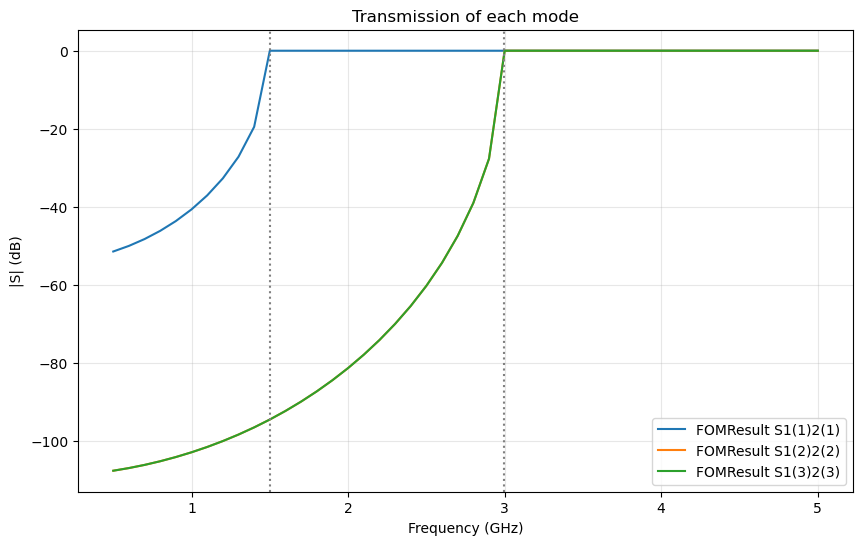

In [8]:
import matplotlib.pyplot as plt

fig, ax = fom.plot_s(["1(1)2(1)", "1(2)2(2)", "1(3)2(3)"], title="Transmission of each mode")
for fc in (1.499, 2.998):
    ax.axvline(fc, color="grey", ls=":")
plt.show()

Each transmission climbs to 0 dB at its own cutoff: mode 1 at 1.5 GHz, modes
2 and 3 at 3.0 GHz (their curves lie on top of each other). Below its cutoff a
mode is evanescent and decays along the guide.

### 4.2 Compare with the exact solution

In a uniform guide each mode travels on its own, with
$S_{21} = e^{-j k_z L}$ and $k_z = \sqrt{k_0^2 - k_c^2}$. We compare mode 1
(TE10) and mode 2 (TE01) with this formula: magnitude in dB on top, phase
below.

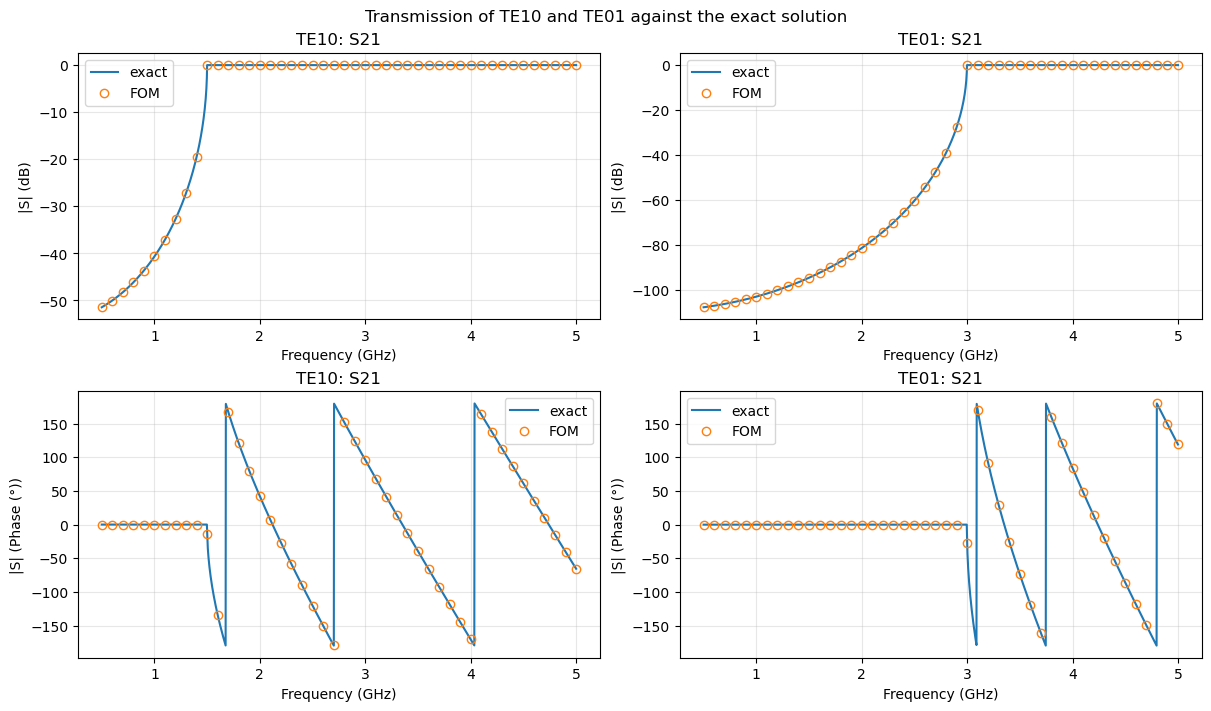

In [9]:
import numpy as np

c0 = 299792458.0
f = res["frequencies"]
f_fine = np.linspace(0.5e9, 5.0e9, 2000)

fig, axs = plt.subplot_mosaic([["TE10 db", "TE01 db"], ["TE10 phase", "TE01 phase"]],
                              figsize=(12, 7), layout="constrained")
for name, kc, label in (("TE10", np.pi / 0.1, "1(1)2(1)"), ("TE01", np.pi / 0.05, "1(2)2(2)")):
    kz = np.sqrt((2 * np.pi * f_fine / c0)**2 - kc**2 + 0j)
    kz = np.where(kz.imag > 0, -kz, kz)
    S21_exact = np.exp(-1j * kz * 0.2)
    axs[f"{name} db"].plot(f_fine / 1e9, 20 * np.log10(np.abs(S21_exact)), label="exact")
    axs[f"{name} phase"].plot(f_fine / 1e9, np.degrees(np.angle(S21_exact)), label="exact")
    for kind in ("db", "phase"):
        fom.plot_s([label], plot_type=kind, ax=axs[f"{name} {kind}"], label="FOM",
                   lw=0, marker="o", mfc="none", title=f"{name}: S21")
fig.suptitle("Transmission of TE10 and TE01 against the exact solution")
plt.show()

Both modes follow the exact curves, above and below their cutoffs.

### 4.3 Check that the modes do not mix

The off-diagonal entries between different modes, for example `'1(1)2(2)'`
(TE10 in at port 1, TE01 out at port 2), measure how much power a structure
converts from one mode into another. A uniform guide converts none:

In [10]:
labels = port_mode_labels(fom)
S = res["S"]
worst = 0.0
for i, out in enumerate(labels):
    for j, inp in enumerate(labels):
        if out[-3:] != inp[-3:]:               # different mode numbers
            worst = max(worst, np.abs(S[:, i, j]).max())
print(f"largest mode-to-mode coupling: {worst:.1e}")

largest mode-to-mode coupling: 4.2e-04


A few times $10^{-4}$: numerical noise, against a transmission of 1. In a
structure with an iris, a step or an off-centre obstacle these entries are not
small, and that is when a port needs the extra modes.

## 5. Give ports different counts

### 5.1 Three modes on port 1, one on port 2

A list gives the counts in port-map order. The request has changed, so
`solve()` recomputes.

In [11]:
res_31 = proj.fds.solve(fmin=0.5, fmax=5.0, nsamples=46, nportmodes=[3, 1],
                        solver_type="direct")
print("S:", res_31["S"].shape)
print("port modes:", port_mode_labels(proj.fds.fom))

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port1 mode 1: TE_01, kc=62.8319, sigma=+1
	port1 mode 2: TE_20, kc=62.8319, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 4 total modes



FDS Solve: 0.5000 - 5.0000 GHz, 46 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 47.93s


S: (46, 4, 4)
port modes: ['1(1)', '1(2)', '1(3)', '2(1)']


Four port modes now: three at port 1 and one at port 2, so a 4 × 4 matrix. The
dictionary form, `nportmodes={"port1": 3, "default": 1}`, gives the same.

### 5.2 Compare the TE10 transmission

The fundamental mode's transmission does not depend on how many other modes
are carried in a uniform guide:

In [12]:
S21_3 = S[:, 3, 0]                    # '1(1)2(1)' with three modes on each port
S21_31 = res_31["S"][:, 3, 0]         # '1(1)2(1)' with [3, 1]
print(f"largest difference: {np.max(np.abs(S21_3 - S21_31)):.1e}")

largest difference: 1.6e-07


## What we did

We gave each port three modes, read the resulting 6 × 6 S-matrix and its port
mode labels, checked the modes' cutoffs and transmissions against the exact
solution, confirmed that a uniform guide does not mix modes, and gave the two
ports different mode counts.

**Next:** [Coaxial line with a dielectric window](../tem_transmission_line.ipynb)
uses TEM ports and compares with CST Studio Suite.

**Background:** [Ports and port modes](../../explanation/ports.md).